https://github.com/FabricioArendTorres/FlowConductor/tree/main

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
import numpy as np
import matplotlib.pyplot as plt

import torch
from msi.flow_conductor import architecture
from msi.flow_conductor.likelihood_flow import LikelihoodFlow

# import tensorflow as tf
# tf.config.experimental.set_memory_growth(tf.config.list_physical_devices(device_type="GPU")[0], True)
# from msi.gaussian_mixture.likelihood_gmm import LikelihoodGMM
# from msi.gaussian_mixture import architecture
# from deep_lss.utils import configuration

from msi.utils import preprocessing
from msfm.utils import prior, parameters, files, logger, observation

# load network predictions

### v4

In [3]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/config.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v4"

# # lensing only

# # large_scales (6 Mpc/h)
# model_dir = "2023-08-28_04-29-33_resnet_vanilla"

# n_steps = 50000
# params = ["Om", "s8", "Aia", "n_Aia"]

In [4]:
# # combined probes
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v4"

# # all parameters
# model_dir = "2023-08-31_03-29-47_resnet_vanilla"

# n_steps = 20000
# params = ["Om", "s8", "H0", "Ob", "ns", "w0", "Aia", "n_Aia", "bg", "n_bg"]

### v6

#### lensing only

In [5]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
# # base_dir = "/pscratch/sd/a/athomsen/run_files/v6/lensing_only"
# base_dir = "/pscratch/sd/a/athomsen/run_files/v6/lensing"

# # delta loss #####################################################################################################

# # longest run, 300k steps with evaluations every 10k
# # model_dir = "delta/2024-01-12_19-35-59_resnet_vanilla"

# # model_dir = "delta/2024-02-06_11-02-57_resnet_vanilla"
# # model_dir = "delta/2024-02-08_08-21-34_resnet_vanilla"

# # biggest run yet, 100k, 200k and 300k evaluations
# # model_dir = "delta/2024-02-09_05-23-03_resnet_vanilla"

# # new, smaller run with evaluations every 10k steps (cashed, buggy)
# # model_dir = "delta/2024-02-12_00-37-01_resnet_vanilla"

# # model_dir = "delta/2024-02-12_06-56-43_resnet_vanilla"

# # new, smaller run with evaluations every 10k steps 
# # model_dir = "likelihood/2024-02-12_02-26-58_resnet_vanilla"

# # vision transformer, delta loss
# # model_dir = "delta/2024-02-13_07-42-20_vit_vanilla"

# # graph transformer, delta loss
# # model_dir = "delta/2024-02-14_02-57-06_gt_vanilla"

# # 1d convolutions, delta loss
# # model_dir = "delta/2024-02-14_01-54-13_oneD_vanilla"

# # with warmup and cosine decay for 100k steps
# model_dir = "lensing/delta/2024-02-22_03-37-44_resnet_vanilla"

# # likelihood loss ################################################################################################

# model_dir = "likelihood/2024-01-22_05-29-26_resnet_vanilla"

# # vision transformer
# # model_dir = "likelihood/2024-02-15_02-41-25_vit_vanilla"


# n_steps = 200000
# params = ["Om", "s8", "w0", "Aia", "n_Aia"]

#### clustering only

#### combined probes

In [6]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v6/combined"

# # delta loss
# # model_dir = "delta/2024-02-02_00-28-48_resnet_vanilla"


# # likelihood loss
# # model_dir = "likelihood/2024-01-30_07-41-40_resnet_vanilla"
# model_dir = "likelihood/2024-02-01_09-02-59_resnet_vanilla"

# n_steps = 200000
# # params = ["Om", "s8", "H0", "Ob", "ns", "w0", "Aia", "n_Aia", "bg", "n_bg"]
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bg", "n_bg"]

# v7

### lensing only

In [7]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v7/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v7/lensing"

# # delta loss #####################################################################################################

# # # with warmup and cosine decay for 100k steps
# # model_dir = "delta/2024-02-22_03-37-44_resnet_vanilla"

# # # with warmup, cosine decay and validation loss, but crashed after 80k steps (visionary-grass-327)
# # model_dir = "delta/2024-02-29_04-19-40_resnet_vanilla"

# # # like the above, but without validation loss (wobbly-durian-328)
# # model_dir = "delta/2024-02-29_05-09-44_resnet_vanilla"

# # # constant learning rate and validation loss for 100k steps (noble-snowball-334)
# # model_dir = "delta/2024-03-02_10-21-45_resnet_vanilla"

# # icy-vortex-344, cosine decay, but reasonable validation loss, jac_weight = 10
# # training loss = -65.46736907958984
# # validation loss = -18.688838958740234
# # model_dir = "delta/2024-03-13_03-40-37_resnet_vanilla"

# # skilled-salad-343, cosine decay, but reasonable validation loss, jac_weight = 100
# # training loss = -58.87385559082031
# # validation loss = -19.380346298217773
# # model_dir = "delta/2024-03-13_03-40-30_resnet_vanilla"

# # curant-cobbler-377, cosine decay, jac_weight = 100, no second to last MLP layer in the regression head
# # training loss = -61.6363525390625
# # validation loss = -17.869802474975586
# model_dir = "delta/2024-03-14_10-10-52_resnet_vanilla"

# # bright-yogurt-408, cosine decay, jac_weight = 100, convolutional regression head (only difference compared to skilled-salad-343)
# # training loss = -64.59732055664062
# # validation loss = -18.545400619506836
# # model_dir = "delta/2024-03-15_08-48-50_resnet_vanilla"

# # polwar-meadow-494, ViT with small patch size
# # model_dir = "delta/2024-03-22_01-19-27_resnet_vanilla"

# # daily-cloud-495, ViT with larger patch size
# # model_dir = "delta/2024-03-22_01-19-30_resnet_vanilla"

# # likelihood loss ################################################################################################

# # # constant learning rate and validation for 100k steps (classic-capybara-333)
# # model_dir = "likelihood/2024-03-01_13-43-31_resnet_vanilla"

# # n_steps = 300000
# # n_steps = 101485
# n_steps = 100000
# params = ["Om", "s8", "w0", "Aia", "n_Aia"]

# v8

### lensing only

In [8]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v8/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v8/lensing"

# # delta loss #####################################################################################################

# # glad-cloud-1011, like curant-cobbler-377, but with the new training set
# # model_dir = "delta/2024-04-22_06-50-39_resnet_vanilla"

# # grateful-firefly-1015, like glad-cloud-1011, but with a constant learning rate
# # model_dir = "delta/2024-04-24_00-27-06_resnet_vanilla"

# # atomic-dream-1016, like glad-cloud-1011, but with twice the number of channels
# # model_dir = "delta/2024-04-24_03-45-06_resnet_vanilla"

# # deep-deluge-1017, like glad-cloud-1011, but without any smoothing (full nside 512/ell_max 1500)
# # model_dir = "delta/2024-04-25_03-29-23_resnet_vanilla"

# # soft-bush-1019, like deep-deluge-1017, but with 60 instead of 20 neighbors in the graph
# # model_dir = "delta/2024-04-25_04-48-49_resnet_vanilla"

# # no smoothing

# # northern-elevator-1024: no smoothing, warmup followed by constant learning rate, 60 neighbors in graph, 100k steps, larger batch size
# # model_dir = "delta/2024-04-26_05-10-36_resnet_vanilla"

# # feasible-monkey-1026: Like northern-elevator-1024, but with a local batch size of four
# model_dir = "delta/2024-04-26_05-39-31_resnet_vanilla"

# n_steps = 50_000
# # n_steps = 55_000
# # n_steps = 60_000
# # n_steps = 65_000
# # n_steps = 100_000
# params = ["Om", "s8", "w0", "Aia", "n_Aia"]

### clustering only

In [9]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v8/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v8/clustering"

# # delta loss #####################################################################################################

# # # revived-blaze-1027, for PASC
# # model_dir = "delta/2024-04-26_05-50-43_resnet_vanilla"
# # n_steps = 80_000

# # # rare-feather-1036, like revived-blaze-1027, but with no l_min 
# # model_dir = "delta/2024-05-06_10-56-24_resnet_vanilla"
# # n_steps = 70_000

# # # rare-yogurt-1038, like rare-feather-1036, but with 1% white noise
# # model_dir = "delta/2024-05-12_01-50-44_resnet_vanilla"
# # n_steps = 60_000

# # still-galaxy-1037, like rare-feather-1036, but with 1% white noise
# model_dir = "delta/2024-05-10_12-33-20_resnet_vanilla"
# n_steps = 80_000

# params = ["Om", "s8", "w0", "bg", "n_bg"]


### combined probes

In [10]:
# # conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v8/linear_bias.yaml")
# # base_dir = "/pscratch/sd/a/athomsen/run_files/v8/combined"

# # # delta loss #####################################################################################################

# # still-glitter-1023: normal smoothing, warmup followed by constant learning rate, 60 neighbors in graph, 100k steps, larger batch size
# model_dir = "delta/2024-04-26_05-10-35_resnet_vanilla"

# # # n_steps = 100_000
# # params = ["Om", "s8", "w0", "Aia", "n_Aia", "bg", "n_bg"]

### for PASC poster

In [11]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v8/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v8"

# # delta loss #####################################################################################################

# # # lensing
# # model_dir = "lensing/delta/2024-04-26_05-50-54_resnet_vanilla"
# # params = ["Om", "s8", "w0", "Aia", "n_Aia"]
# # n_steps = 100_000

# # # clustering
# # model_dir = "clustering/delta/2024-04-26_05-50-43_resnet_vanilla"
# # params = ["Om", "s8", "w0", "bg", "n_bg"]
# # n_steps = 80_000

# # combined
# model_dir = "combined/delta/2024-04-26_17-18-07_resnet_vanilla"
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bg", "n_bg"]
# n_steps = 50_000

# v9

### clustering

In [12]:
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v9/linear_bias.yaml")
base_dir = "/pscratch/sd/a/athomsen/run_files/v9/clustering"

# delta loss #####################################################################################################

# # earnest-wood-1039 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/nmhf2f7f), 10% of noise
# model_dir = "delta/2024-07-17_09-27-28_resnet_vanilla"
# net_conf = "/global/u2/a/athomsen/y3-deep-lss/configs/v9/clustering/resnet_vanilla.yaml"
# n_steps = 60_000

# fresh-sky-1040 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/0r0mzpo9), 1% of noise
model_dir = "delta/2024-07-18_10-16-57_resnet_vanilla"
net_conf = "/global/u2/a/athomsen/y3-deep-lss/configs/v9/clustering/resnet_vanilla.yaml"
n_steps = 60_000

params = ["Om", "s8", "w0", "bg", "n_bg"]

### general

In [13]:
# dataset
fidu_preds, grid_preds, grid_cosmos, file_dict = preprocessing.get_reshaped_network_preds(
    base_dir, model_dir, n_steps, n_params=len(params), n_perms_per_cosmo=4
)

# output directory and file names
out_dir = os.path.join(base_dir, model_dir)
label = ""

24-07-25 06:13:26 input_output INF   Array shapes: 
24-07-25 06:13:26 input_output INF   fiducial/vali/pred = (4000, 5) 
24-07-25 06:13:26 input_output INF   fiducial/vali/i_example = (4000,) 
24-07-25 06:13:26 input_output INF   fiducial/vali/i_noise = (4000,) 
24-07-25 06:13:26 input_output INF   grid/pred          = (2500, 240, 5) 
24-07-25 06:13:26 input_output INF   grid/cosmo         = (2500, 5) 
24-07-25 06:13:26 input_output INF   grid/i_example     = (2500, 240) 
24-07-25 06:13:26 input_output INF   grid/i_noise       = (2500, 240) 
24-07-25 06:13:26 input_output INF   grid/i_sobol       = (2500,) 
24-07-25 06:13:26 preprocessin WAR   Only taking the first 4 permutations per cosmology 
24-07-25 06:13:26 preprocessin WAR   n_patches and n_noise are hard-coded here! 


24-07-25 06:13:26 preprocessin INF   Shapes after concatenation and selection: 
24-07-25 06:13:26 preprocessin INF   fidu_preds  = (4000, 5) 
24-07-25 06:13:26 preprocessin INF   grid_preds  = (120000, 5) 
24-07-2

# likelihood Flow $p(x|\theta)$

### architecture

In [14]:
# input dimensions
x_dim = grid_preds.shape[-1]
theta_dim = grid_cosmos.shape[-1]

# shared hyperparameters
context_embedding_dim = 32

embedding_net = architecture.get_context_embedding_net(
    context_dim=theta_dim,
    context_embedding_dim=context_embedding_dim,
    hidden_dim=64,
    n_blocks=3,
    dropout_probability=0.0,
    use_batch_norm=False,
)    

base_dist = architecture.get_normal_dist(
    feature_dim=x_dim,
)

transform = architecture.get_sigmoids_transform(
    feature_dim=x_dim,
    context_embedding_dim=context_embedding_dim,
    n_layers=4,
    hidden_dim=256,
    svd_kwargs={},
    sigmoids_kwargs={
        "n_sigmoids": 32,
        "num_blocks": 3,
        "dropout_probability": 0.0,
    }
)


# transform = architecture.get_lipschitz_transform(
#     feature_dim=x_dim,
#     context_embedding_dim=context_embedding_dim,
#     n_layers=4,
#     hidden_dim=256,
# )

model = LikelihoodFlow(
    params, 
    conf, 
    embedding_net=embedding_net,
    base_dist=base_dist,
    transform=transform,
    out_dir=out_dir, 
    label=label,
    # load_existing=False,
    load_existing=True,
)

24-07-25 06:13:26 likelihood_b INF   Set up the model directory /pscratch/sd/a/athomsen/run_files/v9/clustering/delta/2024-07-18_10-16-57_resnet_vanilla/likelihood_flow 
24-07-25 06:13:26 likelihood_f INF   Initialized the normalizing flow 
24-07-25 06:13:27 likelihood_f INF   Running on device cuda with default float torch.float32 
24-07-25 06:13:27 likelihood_f INF   Loaded the model from /pscratch/sd/a/athomsen/run_files/v9/clustering/delta/2024-07-18_10-16-57_resnet_vanilla/likelihood_flow/likelihood_flow.pt 


### training

In [15]:
# n_cosmos = file_dict["grid/pred"].shape[0]
# n_examples = grid_preds.shape[0]
# # such that GPU utilization is maximized, but not larger
# batch_size = 4 * n_cosmos
# print(f"batch_size = {batch_size} for {n_examples / batch_size} steps per epoch")

# # default to train from scratch with 4 permutations per grid point
# model.fit(
#     x=grid_preds,
#     theta=grid_cosmos,
#     n_epochs=200,
#     # dataset
#     batch_size=batch_size,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-2,
#     weight_decay=0.0,
#     clip_by_global_norm=1.0,
#     # scheduler
#     scheduler_type="cosine",
#     scheduler_kwargs={"eta_min": 1e-5},
#     # early stopping
#     n_patience_epochs=None,
#     min_delta=1e-5,
#     save_model=True,
# )

In [16]:
# n_cosmos = file_dict["grid/pred"].shape[0]
# n_examples = grid_preds.shape[0]
# # such that GPU utilization is maximized, but not larger
# batch_size = 4 * n_cosmos
# print(f"batch_size = {batch_size} for {n_examples / batch_size} steps per epoch")

# model.fit(
#     x=grid_preds,
#     theta=grid_cosmos,
#     n_epochs=100,
#     # dataset
#     batch_size=batch_size,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-2,
#     weight_decay=0.0,
#     clip_by_global_norm=1.0,
#     # scheduler
#     scheduler_type="exp",
#     scheduler_kwargs={"gamma": 0.95},
#     # early stopping
#     n_patience_epochs=None,
#     min_delta=1e-5,
#     save_model=True,
# )

In [17]:
# # default to train from scratch with 20 permutations per grid point
# model.fit(
#     x=grid_preds,
#     theta=grid_cosmos,
#     n_epochs=200,
#     # dataset
#     batch_size=10000,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-2,
#     weight_decay=0.0,
#     clip_by_global_norm=1.0,
#     # scheduler
#     scheduler_type="cosine",
#     scheduler_kwargs={"eta_min": 1e-5},
#     # early stopping
#     n_patience_epochs=None,
#     min_delta=1e-5,
#     save_model=True,
# )

In [18]:
# n_cosmos = file_dict["grid/pred"].shape[0]
# n_examples = grid_preds.shape[0]
# # such that GPU utilization is maximized, but not larger
# batch_size = 4 * n_cosmos
# print(f"batch_size = {batch_size} for {n_examples / batch_size} steps per epoch")

# # default to train from scratch with 4 permutations per grid point
# model.fit(
#     x=grid_preds,
#     theta=grid_cosmos,
#     n_epochs=200,
#     # dataset
#     batch_size=batch_size,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-2,
#     weight_decay=0.0,
#     clip_by_global_norm=1.0,
#     # scheduler
#     scheduler_type="cosine",
#     scheduler_kwargs={"eta_min": 1e-5},
#     # early stopping
#     n_patience_epochs=None,
#     min_delta=1e-5,
#     save_model=True,
# )

# Gaussian Mixture Model $p(x|\theta)$

### architecture

In [19]:
# layers = architecture.get_gmm_layers(
#     n_x=grid_preds.shape[-1],
#     n_theta=grid_cosmos.shape[1],
#     n_gaussians=8,
#     n_units=256,
#     n_layers=8,
#     activation="relu",
#     dropout_rate=0.1,
# )

# model = LikelihoodGMM(
#     params, 
#     conf,
#     layers=layers,
#     out_dir=out_dir, 
#     label=label,
#     load_existing=False,
# )

### training

In [20]:
# n_cosmos = file_dict["grid/pred"].shape[0]
# n_examples = grid_preds.shape[0]
# # such that GPU utilization is maximized, but not larger
# batch_size = 8 * n_cosmos
# print(f"batch_size = {batch_size} for {n_examples / batch_size} steps per epoch")

# model.fit(
#     x=grid_preds,
#     theta=grid_cosmos,
#     n_epochs=1_000,
#     # dataset
#     batch_size=batch_size,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-3,
#     weight_decay=0.0,
#     clip_by_global_norm=1.0,
#     # schedule
#     # scheduler_kwargs={"factor": 0.75, "patience": 20, "cooldown": 10, "min_lr": 1e-6},
#     scheduler_kwargs={"factor": 0.8, "patience": 10, "cooldown": 5, "min_lr": 1e-6},
#     # scheduler_kwargs={},
#     # early stopping
#     n_patience_epochs=100,
#     min_delta=1e-5,
#     save_model=True,
# )

### convergence tests

In [21]:
# grid_preds_sample = model.plot_diagnostics(
#     # these must be the raw arrays where the cosmo and example axis are still separate
#     grid_preds_true=file_dict["grid/pred"][...,:len(params)], 
#     grid_cosmos=file_dict["grid/cosmo"],
#     n_samples=100,
#     # do_hist=True,
#     do_dlss=True,
#     do_eecp=True,
#     do_tarp=True,
# )

# contours

## observation

### CosmoGrid

In [22]:
# # i_obs = 0
# # # i_obs = np.argmin(np.sum(np.square(np.median(fidu_preds, axis=0, keepdims=True) - fidu_preds), axis=-1))
# # print(f"Using the example index {i_obs}")

# # obs_pred = fidu_preds[i_obs]
# # obs_pred = file_dict["fiducial/vali/pred"][i_obs,...,:len(params)]
# # obs_label = f"fiducial_{i_obs}"

# obs_pred = np.mean(file_dict["fiducial/vali/pred"], axis=0)[:len(params)]
# obs_label = f"fiducial_mean"

# # obs_pred = np.median(file_dict["fiducial/vali/pred"], axis=0)[:len(params)]
# # obs_label = f"fiducial_median"

# obs_point = {str(param): value for param, value in zip(params, parameters.get_fiducials(params))}
# print(obs_pred)

In [23]:
# i_cosmo = 0
# i_example = 0
# # i_obs = 1400
# # i_obs = 2174

# obs_pred = file_dict["grid/pred"][i_cosmo,i_example,:len(params)]
# obs_point = {str(param): value for param, value in zip(params, file_dict["grid/cosmo"][i_cosmo])}

# i_sobol = file_dict["grid/i_sobol"][i_cosmo]
# obs_label = f"grid_{i_sobol}"

# print(obs_pred)
# print(f"i_sobol = {i_sobol}")

### external

In [28]:
# created in y3-deep-lss/notebooks/evaluation/mock_observation.ipynb

obs_label = f"Buzzard"
# # obs_label = f"Cardinal"

# with h5py.File(os.path.join(out_dir, obs_label + "_mock_pred.h5"), "r") as f:
#     obs_pred = f["pred"][:]
    
obs_point = {"Om": 0.286, "s8": 0.82, "w0": -1, "bg": 1.5, "n_bg": 0.5}
# obs_point = {"Om": 0.286, "s8": 0.82, "w0": -1}
# obs_point = [0.286, 0.82, -1]

# buzzard, 1% noise network
# obs_pred = np.array([0.11750833, -0.16671412, -0.01004489, 0.23830356, 0.05534103])
# map * 1.25
obs_pred = np.array([0.14707267, -0.09818453, -0.11372615,  0.52163917, 0.22443816])

# buzzard, 10% noise network
# obs_pred = np.array([0.10610571, 0.02514898, -0.5136099, 0.11173001, 0.1456505])
# map * 1.25
# obs_pred = np.array([0.13469146, 0.19575, -0.48616108, 0.22199535, 0.29827002])

print(obs_pred)

[ 0.14707267 -0.09818453 -0.11372615  0.52163917  0.22443816]


### MCMC

In [29]:
posterior_samples = model.sample_posterior(
    obs_pred,
    label=obs_label,
)

24-07-25 06:15:56      mcmc.py INF   Initial values in prior: True 
24-07-25 06:15:56      mcmc.py INF   Starting the burn in MCMC chain (100 steps) 
24-07-25 06:16:03      mcmc.py INF   Starting the main MCMC chain (500 steps) 


100%|██████████| 500/500 [00:36<00:00, 13.77it/s]

24-07-25 06:16:39      mcmc.py INF   Saved the MCMC chain to /pscratch/sd/a/athomsen/run_files/v9/clustering/delta/2024-07-18_10-16-57_resnet_vanilla/likelihood_flow/chain_Buzzard.npy 


### plotting

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

24-07-25 06:16:43  plotting.py INF   Saved the plot to /pscratch/sd/a/athomsen/run_files/v9/clustering/delta/2024-07-18_10-16-57_resnet_vanilla/likelihood_flow/contours_Buzzard.png 


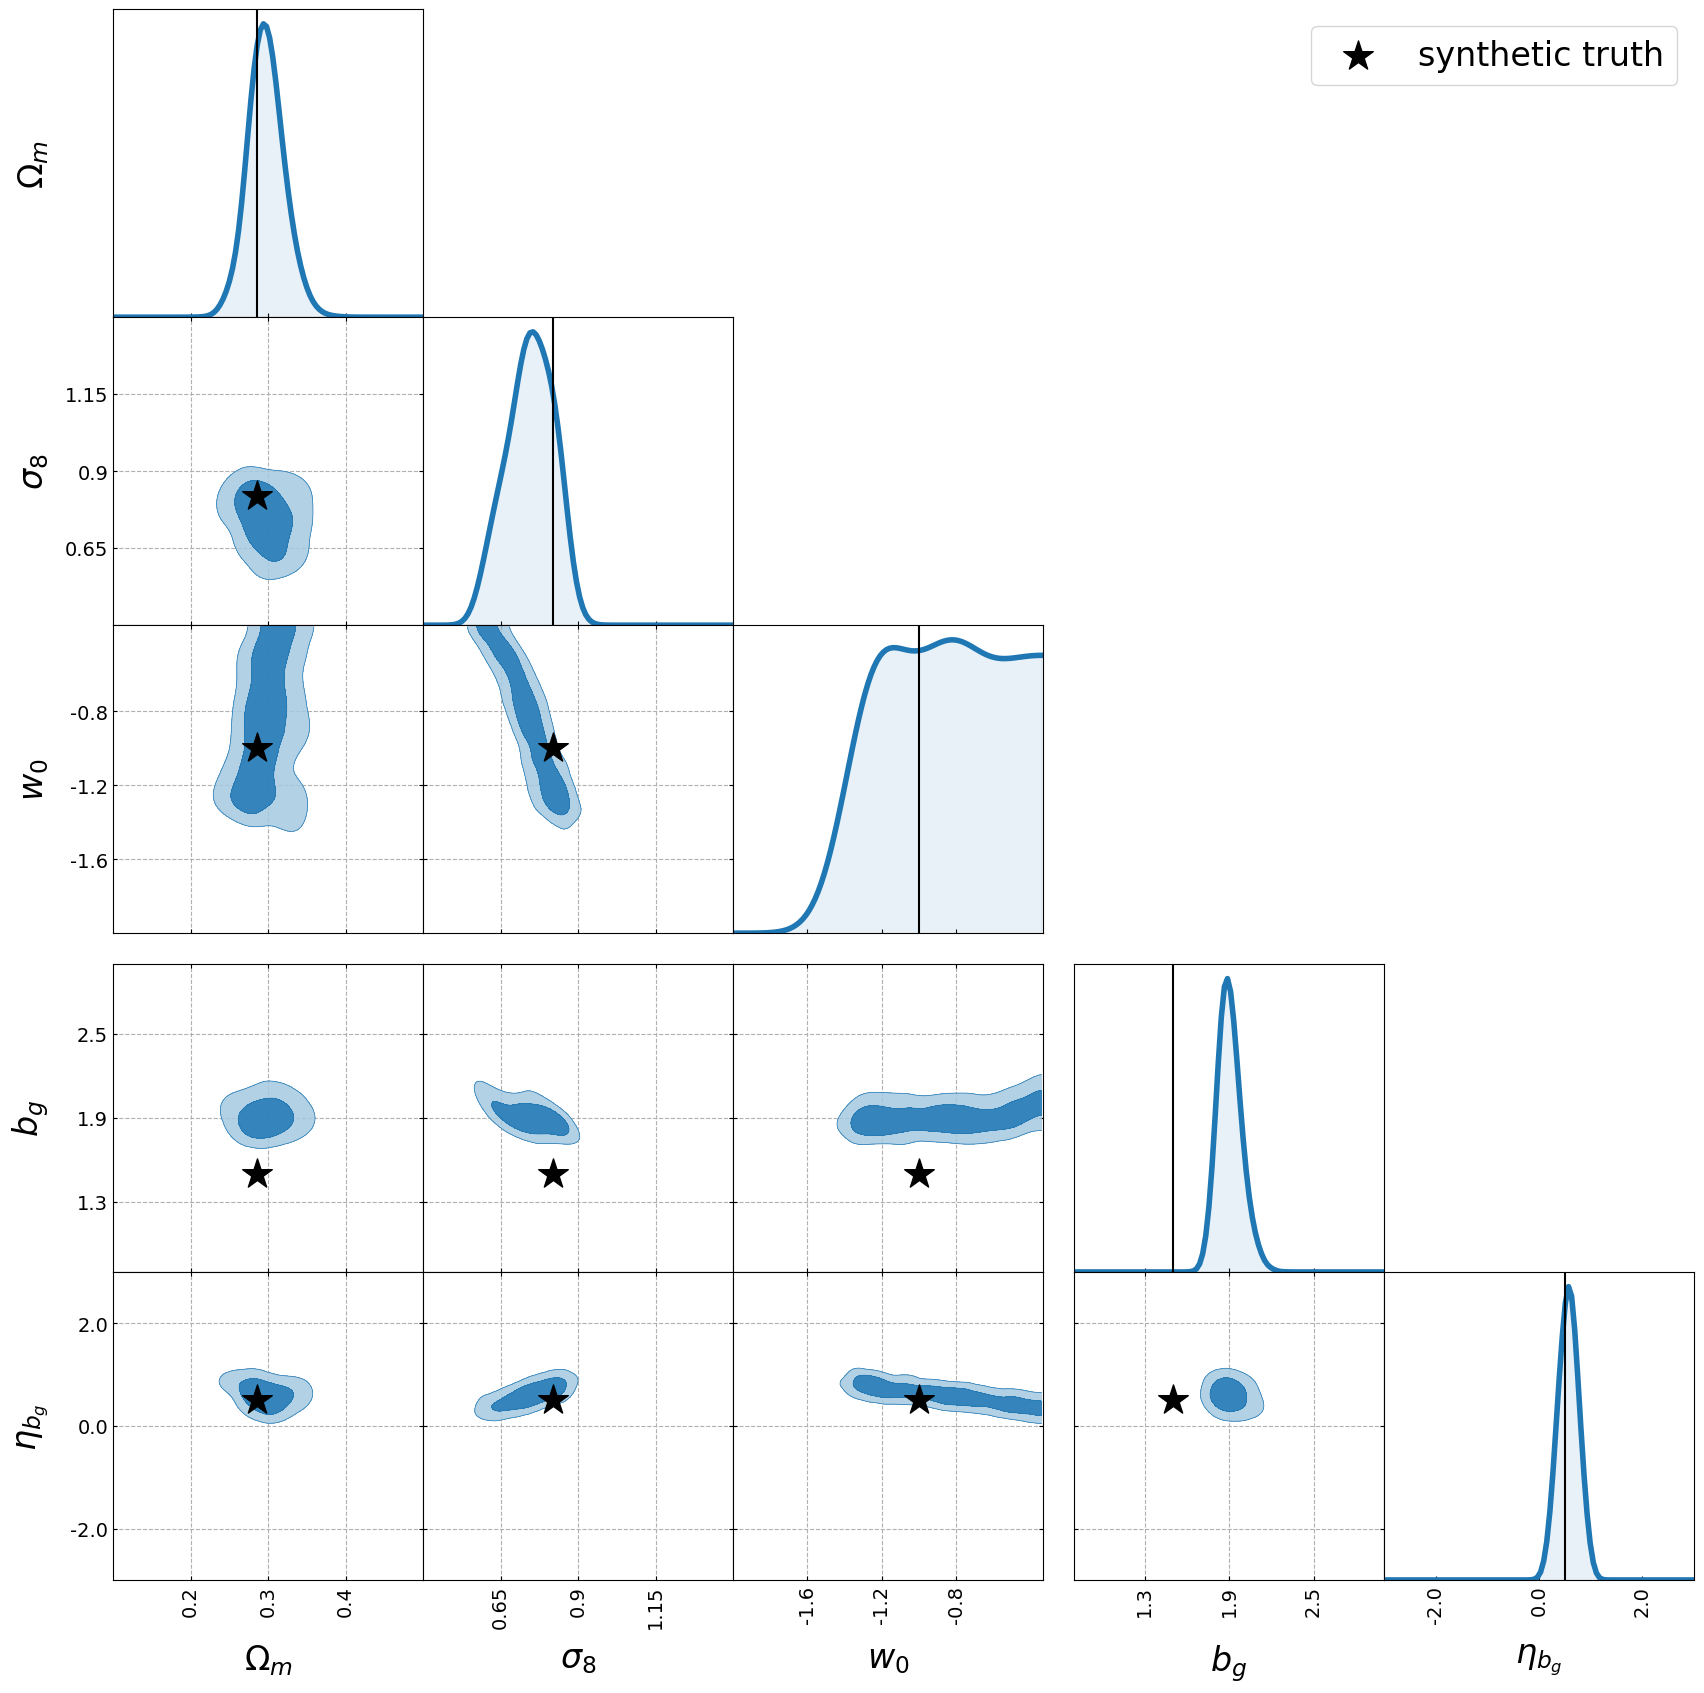

In [30]:
model.plot_contours(
    posterior_samples,
    # plot_fiducial=False,
    fiducial_point=obs_point,
    label=obs_label,
)

In [27]:
# for i_obs in list(range(1,2500,33))[:10]:
#     obs_pred = file_dict["grid/pred"][i_obs]
#     # obs_pred = np.median(obs_pred, axis=0)
#     obs_pred = obs_pred[0]
#     obs_pred = obs_pred[:len(params)]

#     fiducial_point = {str(param): value for param, value in zip(params, file_dict["grid/cosmo"][i_obs])}

#     i_sobol = file_dict["grid/i_sobol"][i_obs]
    
#     posterior_samples = model.sample_posterior(
#         obs_pred,
#     )
    
#     model.plot_contours(
#         posterior_samples,
#         fiducial_point=fiducial_point,
#         label=f"grid_{i_sobol}"
#     )